# Computer Vision Nanodegree

## Project: Image Captioning

---

In this notebook, you will use your trained model to generate captions for images in the test dataset.

This notebook **will be graded**.  

Feel free to use the links below to navigate the notebook:
- [Step 1](#step1): Get Data Loader for Test Dataset 
- [Step 2](#step2): Load Trained Models
- [Step 3](#step3): Finish the Sampler
- [Step 4](#step4): Clean up Captions
- [Step 5](#step5): Generate Predictions!

In [1]:
# --- COCO dataset auto-setup (added) ---
# Ensures the COCO annotations/images this notebook needs exist somewhere writable.
# Tries /opt first (the default `cocoapi_loc` expected by data_loader.py); falls back
# to the home directory or the current directory if /opt isn't writable in this
# workspace. Safe to re-run: anything already downloaded/extracted is skipped.
import os
import urllib.request
import zipfile

def _writable(path):
    try:
        os.makedirs(path, exist_ok=True)
        probe = os.path.join(path, '.write_test')
        with open(probe, 'w') as f:
            f.write('ok')
        os.remove(probe)
        return True
    except OSError:
        return False

COCOAPI_LOC = None
for _root in ['/opt', os.path.expanduser('~'), '/workspace', '.']:
    if _writable(os.path.join(_root, 'cocoapi')):
        COCOAPI_LOC = _root
        break
if COCOAPI_LOC is None:
    raise RuntimeError('Could not find a writable location to store the COCO dataset.')
print('Using COCOAPI_LOC =', COCOAPI_LOC)

_coco_root = os.path.join(COCOAPI_LOC, 'cocoapi')
os.makedirs(os.path.join(_coco_root, 'annotations'), exist_ok=True)
os.makedirs(os.path.join(_coco_root, 'images'), exist_ok=True)

def _download(url, dest):
    if os.path.exists(dest):
        print('Already downloaded:', dest)
        return
    print('Downloading', url, '-> ', dest)
    urllib.request.urlretrieve(url, dest)

def _extract(zip_path, dest_dir, done_marker):
    if os.path.exists(done_marker):
        print('Already extracted:', done_marker)
        return
    print('Extracting', zip_path, '-> ', dest_dir)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(dest_dir)

# Captions + instances annotations (~241 MB) -- covers train2014 and val2014.
_ann_zip = os.path.join(_coco_root, 'annotations_trainval2014.zip')
_download('http://images.cocodataset.org/annotations/annotations_trainval2014.zip', _ann_zip)
_extract(_ann_zip, _coco_root, os.path.join(_coco_root, 'annotations', 'captions_train2014.json'))

# Test image info (small).
_test_info_zip = os.path.join(_coco_root, 'image_info_test2014.zip')
_download('http://images.cocodataset.org/annotations/image_info_test2014.zip', _test_info_zip)
_extract(_test_info_zip, _coco_root, os.path.join(_coco_root, 'annotations', 'image_info_test2014.json'))

# Test images (~6.2 GB).
_test_zip = os.path.join(_coco_root, 'test2014.zip')
_download('http://images.cocodataset.org/zips/test2014.zip', _test_zip)
_extract(_test_zip, os.path.join(_coco_root, 'images'), os.path.join(_coco_root, 'images', 'test2014'))


Using COCOAPI_LOC = /home/student
Extracting /home/student/cocoapi/annotations_trainval2014.zip ->  /home/student/cocoapi
Extracting /home/student/cocoapi/image_info_test2014.zip ->  /home/student/cocoapi
Extracting /home/student/cocoapi/test2014.zip ->  /home/student/cocoapi/images


<a id='step1'></a>
## Step 1: Get Data Loader for Test Dataset

Before running the code cell below, define the transform in `transform_test` that you would like to use to pre-process the test images.  

Make sure that the transform that you define here agrees with the transform that you used to pre-process the training images (in **2_Training.ipynb**).  For instance, if you normalized the training images, you should also apply the same normalization procedure to the test images.

In [2]:
import sys
sys.path.append('/opt/cocoapi/PythonAPI')
from pycocotools.coco import COCO
from data_loader import get_loader
from torchvision import transforms

# TODO #1: Define a transform to pre-process the testing images.
transform_test = transforms.Compose([ 
    transforms.Resize(256),                          # smaller edge of image resized to 256
    transforms.CenterCrop(224),                      # get 224x224 crop from the center
    transforms.ToTensor(),                           # convert the PIL Image to a tensor
    transforms.Normalize((0.485, 0.456, 0.406),      # normalize image for pre-trained model
                         (0.229, 0.224, 0.225))])

#-#-#-# Do NOT modify the code below this line. #-#-#-#

# Create the data loader.
data_loader = get_loader(transform=transform_test,    
                         mode='test',
                         cocoapi_loc=COCOAPI_LOC)

Vocabulary successfully loaded from vocab.pkl file!


Run the code cell below to visualize an example test image, before pre-processing is applied.

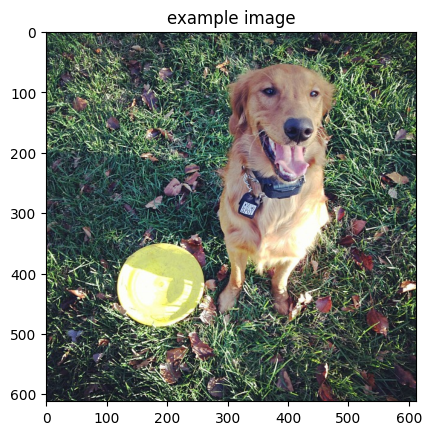

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Obtain sample image before and after pre-processing.
orig_image, image = next(iter(data_loader))

# Visualize sample image, before pre-processing.
plt.imshow(np.squeeze(orig_image))
plt.title('example image')
plt.show()

<a id='step2'></a>
## Step 2: Load Trained Models

In the next code cell we define a `device` that you will use move PyTorch tensors to GPU (if CUDA is available).  Run this code cell before continuing.

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Before running the code cell below, complete the following tasks.

### Task #1

In the next code cell, you will load the trained encoder and decoder from the previous notebook (**2_Training.ipynb**).  To accomplish this, you must specify the names of the saved encoder and decoder files in the `models/` folder (e.g., these names should be `encoder-5.pkl` and `decoder-5.pkl`, if you trained the model for 5 epochs and saved the weights after each epoch).  

### Task #2

Plug in both the embedding size and the size of the hidden layer of the decoder corresponding to the selected pickle file in `decoder_file`.

In [5]:
# Watch for any changes in model.py, and re-load it automatically.
%load_ext autoreload
%autoreload 2

import os
import torch
from model import EncoderCNN, DecoderRNN

# TODO #2: Specify the saved models to load.
encoder_file = 'encoder-3.pkl'
decoder_file = 'decoder-3.pkl'

# TODO #3: Select appropriate values for the Python variables below.
embed_size = 256
hidden_size = 512

# The size of the vocabulary.
vocab_size = len(data_loader.dataset.vocab)

# Initialize the encoder and decoder, and set each to inference mode.
encoder = EncoderCNN(embed_size)
encoder.eval()
decoder = DecoderRNN(embed_size, hidden_size, vocab_size)
decoder.eval()

# Load the trained weights.
encoder.load_state_dict(torch.load(os.path.join('./models', encoder_file)))
decoder.load_state_dict(torch.load(os.path.join('./models', decoder_file)))

# Move models to GPU if CUDA is available.
encoder.to(device)
decoder.to(device)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/student/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 119MB/s] 


DecoderRNN(
  (embed): Embedding(8852, 256)
  (lstm): LSTM(256, 512, batch_first=True)
  (linear): Linear(in_features=512, out_features=8852, bias=True)
)

<a id='step3'></a>
## Step 3: Finish the Sampler

Before executing the next code cell, you must write the `sample` method in the `DecoderRNN` class in **model.py**.  This method should accept as input a PyTorch tensor `features` containing the embedded input features corresponding to a single image.

It should return as output a Python list `output`, indicating the predicted sentence.  `output[i]` is a nonnegative integer that identifies the predicted `i`-th token in the sentence.  The correspondence between integers and tokens can be explored by examining either `data_loader.dataset.vocab.word2idx` (or `data_loader.dataset.vocab.idx2word`).

After implementing the `sample` method, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.  Do **not** modify the code in the cell below. 

In [6]:
# Move image Pytorch Tensor to GPU if CUDA is available.
image = image.to(device)

# Obtain the embedded image features.
features = encoder(image).unsqueeze(1)

# Pass the embedded image features through the model to get a predicted caption.
output = decoder.sample(features)
print('example output:', output)

assert (type(output)==list), "Output needs to be a Python list" 
assert all([type(x)==int for x in output]), "Output should be a list of integers." 
assert all([x in data_loader.dataset.vocab.idx2word for x in output]), "Each entry in the output needs to correspond to an integer that indicates a token in the vocabulary."

example output: [0, 3, 371, 130, 224, 77, 32, 136, 21, 3, 35, 817, 18, 1]


<a id='step4'></a>
## Step 4: Clean up the Captions

In the code cell below, complete the `clean_sentence` function.  It should take a list of integers (corresponding to the variable `output` in **Step 3**) as input and return the corresponding predicted sentence (as a single Python string). 

In [7]:
# TODO #4: Complete the function.
def clean_sentence(output):
    # Map each predicted index back to its word, skipping the special
    # <start>/<end>/<unk> tokens, then join into a single readable sentence.
    words = []
    for idx in output:
        word = data_loader.dataset.vocab.idx2word[idx]
        if word == data_loader.dataset.vocab.start_word:
            continue
        if word == data_loader.dataset.vocab.end_word:
            break
        words.append(word)
    sentence = ' '.join(words)
    sentence = sentence[0].upper() + sentence[1:] + '.'
    return sentence

After completing the `clean_sentence` function above, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.

In [8]:
sentence = clean_sentence(output)
print('example sentence:', sentence)

assert type(sentence)==str, 'Sentence needs to be a Python string!'

example sentence: A dog is sitting in the grass with a red hat ..


<a id='step5'></a>
## Step 5: Generate Predictions!

In the code cell below, we have written a function (`get_prediction`) that you can use to use to loop over images in the test dataset and print your model's predicted caption.

In [9]:
def get_prediction():
    orig_image, image = next(iter(data_loader))
    plt.imshow(np.squeeze(orig_image))
    plt.title('Sample Image')
    plt.show()
    image = image.to(device)
    features = encoder(image).unsqueeze(1)
    output = decoder.sample(features)    
    sentence = clean_sentence(output)
    print(sentence)

Run the code cell below (multiple times, if you like!) to test how this function works.

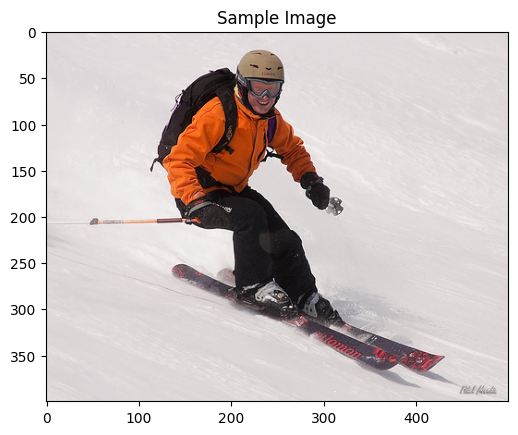

A man riding a snowboard down a snow covered slope ..


In [10]:
get_prediction()

As the last task in this project, you will loop over the images until you find four image-caption pairs of interest:
- Two should include image-caption pairs that show instances when the model performed well.
- Two should highlight image-caption pairs that highlight instances where the model did not perform well.

Use the four code cells below to complete this task.

### The model performed well!

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively accurate captions.

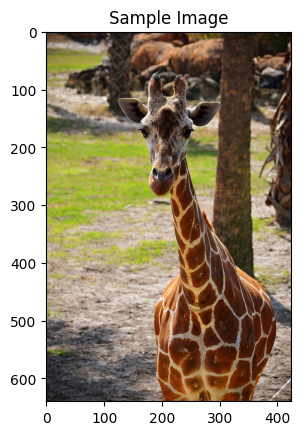

A giraffe standing in a field with a tree in the background ..


In [11]:
get_prediction()

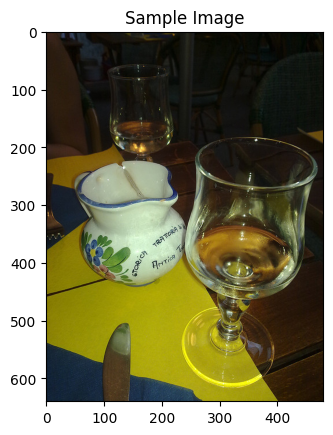

A glass of wine and a glass of wine.


In [12]:
get_prediction()

### The model could have performed better ...

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively inaccurate captions.

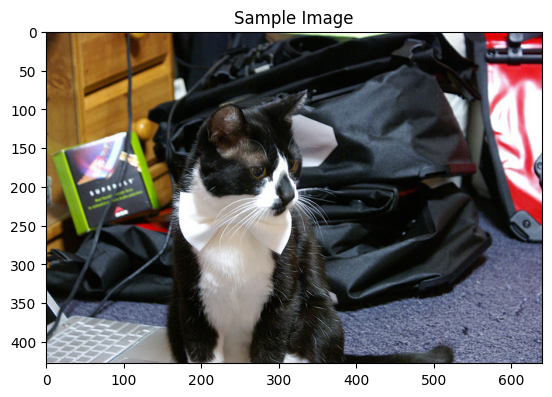

A cat is sitting on top of a laptop computer ..


In [13]:
get_prediction()

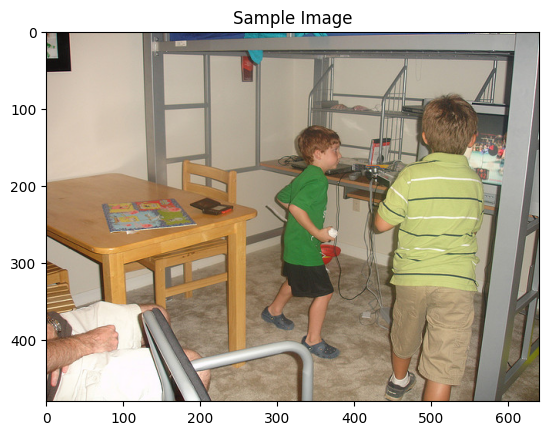

A man and woman are standing in a kitchen ..


In [14]:
get_prediction()